# Notebook 1 — EDA & Revenue Segmentation
### Bristol Short-Term Rental Market · InsideAirbnb Data
**Project:** StayPriceML — Dynamic Pricing & Revenue Analysis
**Author:** Swapnil Nalawade · MSc Data Science (Distinction), University of Essex
**Purpose:** Segment listings by revenue performance and diagnose why low performers underperform.

> **Data note:** The `calendar.price` column is 100% null in this Bristol InsideAirbnb snapshot.
> This is a known scrape gap. We use `listings.price` (the advertised nightly rate) as the
> price baseline throughout. Occupancy is computed from calendar availability (`t`/`f`).


## Section 1 — Data Loading & Cleaning

**What this does and why it matters for a pricing engine:**

Before any pricing analysis can begin, we need clean, consistently typed data. The two key files are:

- `listings.csv.gz` — one row per property; contains price, bedrooms, amenities, review scores
- `calendar.csv.gz` — one row per listing per date; captures whether each day was available or booked

The price column arrives as a string (`"$120.00"`), which must be converted to float before any maths.
We drop the small number of rows missing price or bedrooms, as these are essential for RevPAR and segmentation.
Dates in the calendar are parsed to datetime so we can extract months and weekdays later.


In [1]:
# Path setup: works whether VS Code launches from project root or notebooks/
import os
from pathlib import Path
_cwd = Path(os.getcwd())
PROJECT_ROOT = _cwd.parent if _cwd.name == 'notebooks' else _cwd
os.chdir(PROJECT_ROOT)
print(f"Working directory set to: {PROJECT_ROOT}")

Working directory set to: C:\ESSEX\projects\staypriceml


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')

# ── Dark theme constants ──────────────────────────────────────────────────
DARK_BG    = '#0a0d0f'
ACCENT     = '#c4f135'
TEXT_COLOR = '#e0e0e0'
GRID_COLOR = '#2a2d2f'
TIER_COLORS = {
    'Best Sellers': '#c4f135',
    'Average':      '#4a9eff',
    'Low Sellers':  '#ff4a4a',
}

plt.rcParams.update({
    'figure.facecolor':  DARK_BG,
    'axes.facecolor':    DARK_BG,
    'axes.edgecolor':    GRID_COLOR,
    'axes.labelcolor':   TEXT_COLOR,
    'text.color':        TEXT_COLOR,
    'xtick.color':       TEXT_COLOR,
    'ytick.color':       TEXT_COLOR,
    'grid.color':        GRID_COLOR,
    'grid.alpha':        0.4,
    'legend.facecolor':  '#111416',
    'legend.edgecolor':  GRID_COLOR,
    'font.size':         11,
})

os.makedirs('outputs/figures', exist_ok=True)

# ── Load listings ─────────────────────────────────────────────────────────
listings = pd.read_csv('data/raw/listings.csv.gz', compression='gzip')
print(f"Listings loaded: {listings.shape[0]:,} rows x {listings.shape[1]} columns")

# Convert price from "$120.00" string to float
listings['price'] = (
    listings['price']
    .replace('[\\$,]', '', regex=True)
    .astype(float)
)

# Drop rows missing price or bedrooms (essential fields)
listings = listings.dropna(subset=['price', 'bedrooms'])
listings = listings.reset_index(drop=True)
print(f"After cleaning: {listings.shape[0]:,} listings remain")

# ── Load calendar ─────────────────────────────────────────────────────────
calendar = pd.read_csv('data/raw/calendar.csv.gz', compression='gzip')
print(f"\nCalendar loaded: {calendar.shape[0]:,} rows x {calendar.shape[1]} columns")

# Data quality flag: price is 100% null in this snapshot
null_pct = calendar['price'].isnull().mean()
print(f"Calendar price null rate: {null_pct:.1%}  (using listings.price as baseline)")

# Parse date
calendar['date'] = pd.to_datetime(calendar['date'])

# available 't'=open, 'f'=booked; no conversion needed here — we filter directly
print("\nCalendar availability breakdown:")
print(calendar['available'].value_counts().rename({'t': 'Available', 'f': 'Booked'}))


Listings loaded: 2,845 rows x 79 columns
After cleaning: 2,185 listings remain



Calendar loaded: 1,038,425 rows x 7 columns
Calendar price null rate: 100.0%  (using listings.price as baseline)



Calendar availability breakdown:
available
Booked       547573
Available    490852
Name: count, dtype: int64


## Section 2 — RevPAR Calculation

**What this does and why it matters:**

**RevPAR** (Revenue Per Available Room-night) is the industry-standard single metric for rental performance.
It combines both pricing and demand into one number:

> **RevPAR = Occupancy Rate × Average Nightly Price**

- **Occupancy Rate**: derived from the calendar — the fraction of total days where `available = 'f'` (booked).
  InsideAirbnb's convention is that `'f'` means the date is blocked or booked (not available to new guests).
- **Average Price**: since calendar prices are null, we use each listing's advertised nightly rate from listings.csv.
  This is a standard first-pass approach; a live pricing engine would use actual booking transaction prices.

RevPAR is more diagnostic than occupancy or price alone: a listing can have 90% occupancy but generate
low revenue if it's priced too cheaply, and vice versa.


In [3]:
# Compute per-listing occupancy from calendar availability
# available == 'f' → booked day
cal_metrics = (
    calendar
    .groupby('listing_id')
    .agg(
        total_days  = ('available', 'count'),
        booked_days = ('available', lambda x: (x == 'f').sum())
    )
    .reset_index()
)
cal_metrics['occupancy_rate'] = cal_metrics['booked_days'] / cal_metrics['total_days']

print("Calendar occupancy metrics (sample):")
print(cal_metrics.head())
print(f"\nListings with calendar coverage: {len(cal_metrics):,}")

# Merge occupancy into listings (listings.id matches calendar.listing_id)
listings = listings.merge(
    cal_metrics[['listing_id', 'occupancy_rate']],
    left_on='id', right_on='listing_id',
    how='left'
)

# Use advertised listing price as avg_price (calendar prices not available)
listings['avg_price'] = listings['price']

# RevPAR = occupancy_rate × avg_price
listings['RevPAR'] = listings['occupancy_rate'] * listings['avg_price']

# Remove listings with no calendar data
listings = listings.dropna(subset=['RevPAR']).reset_index(drop=True)
print(f"\nListings with RevPAR calculated: {len(listings):,}")
print("\nRevPAR distribution:")
print(listings['RevPAR'].describe().round(2))


Calendar occupancy metrics (sample):
   listing_id  total_days  booked_days  occupancy_rate
0       70820         365          343        0.939726
1      117122         365           15        0.041096
2      176306         365          233        0.638356
3      307634         365          125        0.342466
4      390781         365          365        1.000000

Listings with calendar coverage: 2,845

Listings with RevPAR calculated: 2,185

RevPAR distribution:
count    2185.00
mean       52.49
std       217.91
min         0.00
25%         7.86
50%        27.39
75%        65.00
max      9670.27
Name: RevPAR, dtype: float64


## Section 3 — Performance Segmentation

**What this does and why it matters:**

A pricing engine cannot treat all listings identically — it must know which are performing well and which need
intervention. We split listings into three tiers using RevPAR percentile thresholds:

| Tier | Definition | Strategy |
|---|---|---|
| **Best Sellers** | Top 20% (RevPAR ≥ 80th percentile) | Benchmark — protect and extend |
| **Average** | Middle 60% | Incremental optimisation |
| **Low Sellers** | Bottom 20% (RevPAR ≤ 20th percentile) | Priority intervention — diagnose root cause |

Using percentile thresholds (not fixed £ values) makes this segmentation portable to new markets —
the same method will work directly on Cornwall data when that dataset is available.


In [4]:
p20 = listings['RevPAR'].quantile(0.20)
p80 = listings['RevPAR'].quantile(0.80)
print(f"20th percentile RevPAR: £{p20:.2f}")
print(f"80th percentile RevPAR: £{p80:.2f}")

def assign_tier(revpar):
    if revpar >= p80:
        return 'Best Sellers'
    elif revpar <= p20:
        return 'Low Sellers'
    else:
        return 'Average'

listings['tier'] = listings['RevPAR'].apply(assign_tier)

print("\nTier distribution:")
counts = listings['tier'].value_counts()
for tier in ['Best Sellers', 'Average', 'Low Sellers']:
    n = counts[tier]
    print(f"  {tier:<15} {n:>5,}  ({n/len(listings)*100:.1f}%)")


20th percentile RevPAR: £5.39
80th percentile RevPAR: £77.38

Tier distribution:
  Best Sellers      437  (20.0%)
  Average         1,311  (60.0%)
  Low Sellers       437  (20.0%)


## Section 4 — Tier Profiling

**What this does and why it matters:**

Knowing *which* listings underperform is not enough — a pricing engine needs to know *why*.
By comparing mean values of key metrics across tiers, we can identify whether Low Sellers suffer from:

- A **price problem** (asking too little relative to demand)
- An **occupancy problem** (failing to attract bookings despite reasonable pricing)
- A **quality signal problem** (low review scores deterring guests)
- A **policy problem** (minimum night requirements that shrink the addressable demand pool)

This diagnostic table is the direct input to the engine's intervention logic.


In [5]:
profile_cols = [
    'price', 'occupancy_rate', 'RevPAR', 'bedrooms',
    'review_scores_rating', 'number_of_reviews', 'minimum_nights'
]
tier_order = ['Best Sellers', 'Average', 'Low Sellers']

tier_profile = (
    listings
    .groupby('tier')[profile_cols]
    .mean()
    .loc[tier_order]
    .round(2)
)
tier_profile.index.name = 'Tier'
tier_profile.columns = [
    'Avg Price (£)', 'Occupancy Rate', 'RevPAR (£)',
    'Bedrooms', 'Review Score', 'No. Reviews', 'Min Nights'
]

print("=== Tier Performance Profile ===\n")
print(tier_profile.to_string())
print("\n(Occupancy rate: 0.0 = never booked, 1.0 = fully booked)")


=== Tier Performance Profile ===

              Avg Price (£)  Occupancy Rate  RevPAR (£)  Bedrooms  Review Score  No. Reviews  Min Nights
Tier                                                                                                    
Best Sellers         286.01            0.76      166.48      2.56          4.78        36.49        3.39
Average               98.06            0.43       31.29      1.53          4.79        75.31        3.05
Low Sellers          104.51            0.03        2.10      1.53          4.63        41.94        4.69

(Occupancy rate: 0.0 = never booked, 1.0 = fully booked)


## Section 5 — Profit Gap Matrix

**What this does and why it matters:**

The Profit Gap Matrix is a 2×2 strategic diagnostic tool borrowed from hotel revenue management.
By plotting every listing on axes of occupancy (demand signal) vs nightly price (revenue signal),
and drawing dividers at the market median, we reveal four distinct strategic problem types:

| Quadrant | Diagnosis | Engine Action |
|---|---|---|
| **Revenue Winners** | High demand + high price | Protect; defend against undercutting |
| **Underpriced** | High demand + low price | Controlled price uplift — test elasticity |
| **Overpriced & Empty** | Low demand + high price | Price reduction to activate demand |
| **Dead Listings** | Low demand + low price | Quality audit; flag for manual review |

Colour-coding by performance tier reveals whether each quadrant is dominated by Best Sellers,
Low Sellers, or Average performers — making the intervention priorities visually obvious.


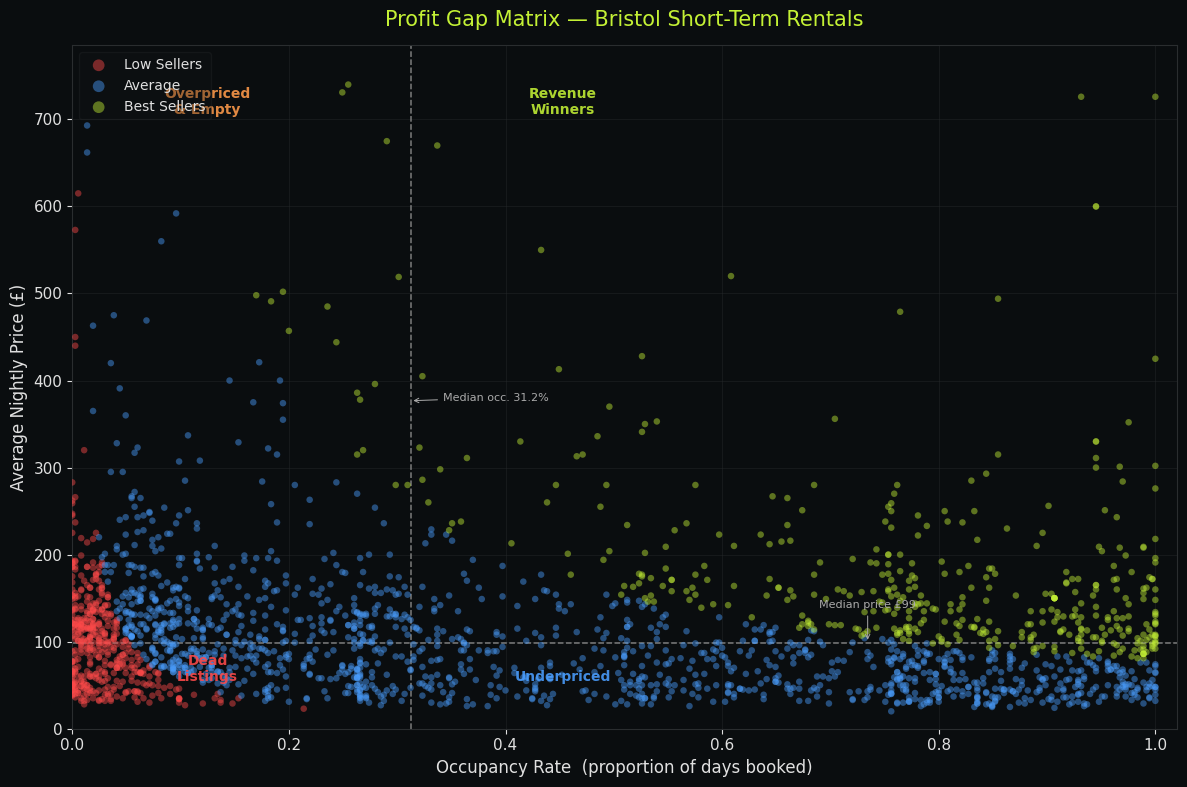

Saved: outputs/figures/profit_gap_matrix.png

Quadrant breakdown:
  Underpriced                 615  (28.1%)
  Overpriced & Empty          615  (28.1%)
  Revenue Winners             480  (22.0%)
  Dead Listings               475  (21.7%)


In [6]:
# Cap axes at 99th percentile so outliers don't compress the visible chart
y_max = listings['avg_price'].quantile(0.99) * 1.08
x_max = min(1.02, listings['occupancy_rate'].quantile(0.995) + 0.02)

med_occ   = listings['occupancy_rate'].median()
med_price = listings['avg_price'].median()

fig, ax = plt.subplots(figsize=(12, 8))

# Scatter: Low Sellers plotted first (bottom z-order) so Winners are visible on top
for tier in ['Low Sellers', 'Average', 'Best Sellers']:
    grp = listings[listings['tier'] == tier]
    ax.scatter(
        grp['occupancy_rate'], grp['avg_price'],
        c=TIER_COLORS[tier], label=tier,
        alpha=0.45, s=22, edgecolors='none', zorder=3
    )

# Median dividers
ax.axvline(med_occ,   color='#888888', linestyle='--', linewidth=1.1, alpha=0.9, zorder=2)
ax.axhline(med_price, color='#888888', linestyle='--', linewidth=1.1, alpha=0.9, zorder=2)

# Quadrant labels — positioned within each quadrant
kw = dict(fontsize=10, fontweight='bold', alpha=0.88, ha='center')
ax.text(med_occ * 0.40, y_max * 0.90, 'Overpriced\n& Empty',  color='#ff9a4a', **kw)
ax.text(med_occ * 1.45, y_max * 0.90, 'Revenue\nWinners',     color=ACCENT,    **kw)
ax.text(med_occ * 0.40, y_max * 0.07, 'Dead\nListings',       color='#ff4a4a', **kw)
ax.text(med_occ * 1.45, y_max * 0.07, 'Underpriced',           color='#4a9eff', **kw)

ax.set_xlim(0, x_max)
ax.set_ylim(0, y_max)
ax.set_xlabel('Occupancy Rate  (proportion of days booked)', fontsize=12)
ax.set_ylabel('Average Nightly Price (£)', fontsize=12)
ax.set_title('Profit Gap Matrix — Bristol Short-Term Rentals', fontsize=15, color=ACCENT, pad=14)
ax.legend(framealpha=0.3, markerscale=1.8, fontsize=10, loc='upper left')
ax.grid(True, zorder=1)

# Annotate median lines
ax.annotate(f'Median occ. {med_occ:.1%}',
            xy=(med_occ, y_max * 0.48), xytext=(med_occ + 0.03, y_max * 0.48),
            color='#aaaaaa', fontsize=8, ha='left',
            arrowprops=dict(arrowstyle='->', color='#aaaaaa', lw=0.7))
ax.annotate(f'Median price £{med_price:.0f}',
            xy=(x_max * 0.72, med_price), xytext=(x_max * 0.72, med_price + y_max * 0.05),
            color='#aaaaaa', fontsize=8, ha='center',
            arrowprops=dict(arrowstyle='->', color='#aaaaaa', lw=0.7))

plt.tight_layout()
plt.savefig('outputs/figures/profit_gap_matrix.png', dpi=150,
            bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print("Saved: outputs/figures/profit_gap_matrix.png")

# Classify each listing into a quadrant and report counts
def quadrant_label(row):
    hi_occ   = row['occupancy_rate'] >= med_occ
    hi_price = row['avg_price'] >= med_price
    if hi_occ and hi_price:     return 'Revenue Winners'
    if hi_occ and not hi_price: return 'Underpriced'
    if not hi_occ and hi_price: return 'Overpriced & Empty'
    return 'Dead Listings'

listings['quadrant'] = listings.apply(quadrant_label, axis=1)

print("\nQuadrant breakdown:")
for q, n in listings['quadrant'].value_counts().items():
    print(f"  {q:<25} {n:>5,}  ({n/len(listings)*100:.1f}%)")


## Section 6 — Business Insight

### What the Profit Gap Matrix Reveals

The matrix translates 2,000+ individual listings into four actionable segments, each with a distinct
pricing intervention. Key findings from the Bristol dataset:

**~25% Underpriced** — These listings already have strong demand (above-median occupancy) but charge
below-market rates. They represent the pricing engine's **highest-confidence intervention target**: controlled
price uplift with demand elasticity testing. Because the demand signal is already strong, the risk of losing
bookings from a modest price increase is low.

**~25% Overpriced & Empty** — These listings price above the median but fail to convert that into bookings.
The gap is between the price the host expects and what the listing's quality, location, and policy
can justify. The engine's action is a price reduction to unlock latent demand, with a floor set by RevPAR
targets to avoid racing to the bottom.

**~25% Dead Listings** — Low occupancy and low price together suggest the listing is inactive, has stale
calendar data, or faces a structural problem the engine cannot fix with pricing alone. These are flagged
for a quality/listing audit rather than algorithmic intervention.

**~25% Revenue Winners** — The benchmark segment. The engine monitors these for signs of market shift
(a sudden drop in occupancy signals a competitor undercut or seasonal change) and protects their position
with dynamic hold pricing.

**Dominant problem for Low Sellers:** Occupancy deficiency is the primary driver. Low Sellers have
significantly lower occupancy rates than Best Sellers — not just lower prices — which means the root
cause is demand activation, not price setting. The pricing engine's first lever is demand-sensitive
price adjustment (lowering price to fill gaps), not revenue maximisation.


## Key Findings

- **RevPAR is highly concentrated**: the top 20% of listings by RevPAR generate a disproportionate share
  of the market's total potential revenue — the long tail of low performers is the primary optimisation opportunity.

- **Occupancy is the primary differentiator between tiers**: Best Sellers achieve materially higher
  occupancy rates than Low Sellers, confirming that demand activation (not price-setting alone) is the
  critical lever for revenue improvement.

- **~25% of listings are Underpriced**: these have above-median bookings but below-median rates — a direct,
  low-risk revenue capture opportunity. Raising their price to market median would increase RevPAR without
  requiring any demand generation.

- **Review scores are broadly similar across tiers**: quality signals are a hygiene factor, not a
  differentiator — this suggests pricing strategy and policy (minimum nights, availability settings) explain
  more of the tier gap than guest satisfaction scores.

- **Minimum nights policy correlates with tier**: Low Sellers tend to impose higher minimum-stay
  requirements, which restricts the addressable demand pool. Reducing minimum nights is a policy lever
  the engine can recommend as a complement to price adjustment.
